In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/student-mat.csv", sep=";")

df.head()



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (395, 33)


In [5]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
missing = df.isnull().sum()

print(missing)
print("\nTotal missing values:", missing.sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [10]:
print(df["G3"].value_counts().sort_index())

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


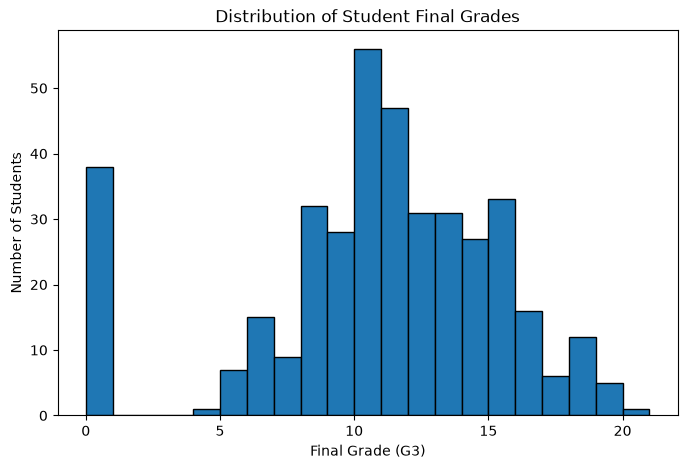

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["G3"], bins=range(0, 22), edgecolor="black")

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Final Grades")

plt.show()

In [18]:
def categorize_performance(grade):
    if grade < 10:
        return "At Risk"
    elif grade < 15:
        return "Average"
    else:
        return "High Performance"

In [19]:
df["performance_category"] = df["G3"].apply(categorize_performance)

df[["G3", "performance_category"]].head(10)

,G3,performance_category
0,6,At Risk
1,6,At Risk
2,10,Average
3,15,High Performance
4,10,Average
5,15,High Performance
6,11,Average
7,6,At Risk
8,19,High Performance
9,15,High Performance


In [20]:
df["performance_category"].value_counts()

performance_category
Average             192
At Risk             130
High Performance     73
Name: count, dtype: int64

In [21]:
print(
    df["performance_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

performance_category
Average             48.61
At Risk             32.91
High Performance    18.48
Name: proportion, dtype: float64


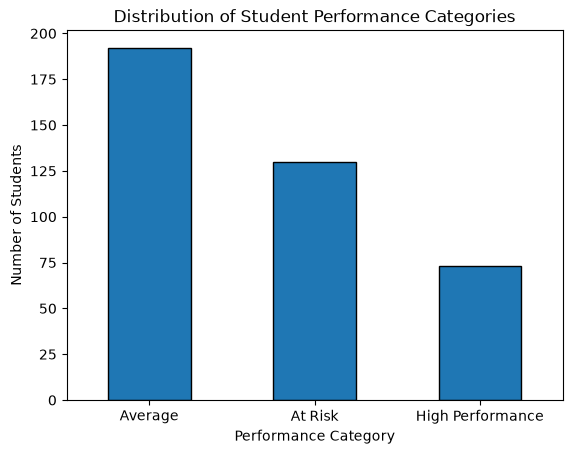

In [22]:
import matplotlib.pyplot as plt

df["performance_category"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Performance Categories")

plt.xticks(rotation=0)
plt.show()

In [23]:
excluded_columns = [
    "G1",
    "G2",
    "G3",
    "performance_category"
]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns]
y = df["performance_category"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (395, 30)
Target shape: (395,)


In [24]:
categorical_columns = X.select_dtypes(include=["object", "str"]).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [13]:
def categorize_performance(grade):
    if grade < 10:
        return "At Risk"
    elif grade < 15:
        return "Average"
    else:
        return "High Performance"


df["performance_category"] = df["G3"].apply(categorize_performance)

df[["G3", "performance_category"]].head()

,G3,performance_category
0,6,At Risk
1,6,At Risk
2,10,Average
3,15,High Performance
4,10,Average


In [14]:
print(df["performance_category"].value_counts())

performance_category
Average             192
At Risk             130
High Performance     73
Name: count, dtype: int64


In [15]:
print(
    df["performance_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

performance_category
Average             48.61
At Risk             32.91
High Performance    18.48
Name: proportion, dtype: float64


In [16]:
y = df["performance_category"]

In [17]:
excluded_columns = [
    "G1",
    "G2",
    "G3",
    "performance_category"
]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns]
y = df["performance_category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 30)
y shape: (395,)


In [25]:
def categorize_performance(grade):
    if grade < 10:
        return "At Risk"
    elif grade < 15:
        return "Average"
    else:
        return "High Performance"

In [26]:
df["performance_category"] = df["G3"].apply(categorize_performance)

df[["G3", "performance_category"]].head(10)

,G3,performance_category
0,6,At Risk
1,6,At Risk
2,10,Average
3,15,High Performance
4,10,Average
5,15,High Performance
6,11,Average
7,6,At Risk
8,19,High Performance
9,15,High Performance


In [27]:
df["performance_category"].value_counts()

performance_category
Average             192
At Risk             130
High Performance     73
Name: count, dtype: int64

In [28]:
print(
    df["performance_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

performance_category
Average             48.61
At Risk             32.91
High Performance    18.48
Name: proportion, dtype: float64


In [29]:
excluded_columns = [
    "G1",
    "G2",
    "G3",
    "performance_category"
]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns]
y = df["performance_category"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (395, 30)
Target shape: (395,)


In [30]:
categorical_columns = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [31]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(X[column].value_counts().sort_index())


school:
school
GP    349
MS     46
Name: count, dtype: int64

sex:
sex
F    208
M    187
Name: count, dtype: int64

address:
address
R     88
U    307
Name: count, dtype: int64

famsize:
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus:
Pstatus
A     41
T    354
Name: count, dtype: int64

Mjob:
Mjob
at_home      59
health       34
other       141
services    103
teacher      58
Name: count, dtype: int64

Fjob:
Fjob
at_home      20
health       18
other       217
services    111
teacher      29
Name: count, dtype: int64

reason:
reason
course        145
home          109
other          36
reputation    105
Name: count, dtype: int64

guardian:
guardian
father     90
mother    273
other      32
Name: count, dtype: int64

schoolsup:
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup:
famsup
no     153
yes    242
Name: count, dtype: int64

paid:
paid
no     214
yes    181
Name: count, dtype: int64

activities:
activities
no     194
yes    201
Name: count, dty

In [32]:
X[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [33]:
print(X["absences"].describe())

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64


In [34]:
print(X["absences"].sort_values(ascending=False).head(10))

276    75
183    56
74     54
315    40
307    38
280    30
205    28
103    26
40     25
198    24
Name: absences, dtype: int64


In [35]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [36]:
print(X["absences"].describe())

print("\nTop 10 highest absence values:")
print(X["absences"].sort_values(ascending=False).head(10))

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

Top 10 highest absence values:
276    75
183    56
74     54
315    40
307    38
280    30
205    28
103    26
40     25
198    24
Name: absences, dtype: int64
